In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
import sklearn.model_selection as model_selection
import sklearn.metrics as metrics

df_bruto= pd.read_csv('sinasc_pa_2026.csv')
df_bruto.head(5)


,ORIGEM,CODESTAB,CODMUNNASC,LOCNASC,IDADEMAE,ESTCIVMAE,ESCMAE,CODOCUPMAE,QTDFILVIVO,QTDFILMORT,...,TPDOCRESP,DTDECLARAC,ESCMAEAGR1,STDNEPIDEM,STDNNOVA,CODPAISRES,TPROBSON,PARIDADE,KOTELCHUCK,CONTADOR
0,1,2515598.0,110002,1,34,2.0,4.0,622020.0,1.0,2.0,...,3.0,20042026.0,6.0,1,1,1,5,1,2,555
1,1,2013282.0,130014,1,24,1.0,4.0,999992.0,0.0,0.0,...,3.0,9042026.0,4.0,1,1,1,2,0,5,23568
2,1,2013282.0,130014,1,27,1.0,4.0,622020.0,2.0,0.0,...,3.0,7082026.0,6.0,1,1,1,3,1,5,23642
3,1,2012480.0,130260,1,28,1.0,4.0,516115.0,1.0,0.0,...,4.0,2032026.0,6.0,1,1,1,3,1,5,37006
4,1,3151794.0,130260,1,18,1.0,4.0,631105.0,1.0,0.0,...,5.0,20022026.0,6.0,1,1,1,3,1,2,37693


In [2]:
colunas = ["CODMUNRES", "CODMUNNASC", "LOCNASC", "IDADEMAE", "ESTCIVMAE", "ESCMAE", "QTDFILVIVO", "GESTACAO", "GRAVIDEZ", "PARTO", "CONSULTAS", "DTNASC", "SEXO", "APGAR5", "RACACOR", "PESO", "SEMAGESTAC", "CONSPRENAT"]
df = df_bruto[colunas].copy()
df.isna().sum()

CODMUNRES        0
CODMUNNASC       0
LOCNASC          0
IDADEMAE         0
ESTCIVMAE      204
ESCMAE         801
QTDFILVIVO     703
GESTACAO       918
GRAVIDEZ        59
PARTO           50
CONSULTAS        0
DTNASC           0
SEXO             0
APGAR5         892
RACACOR        399
PESO            16
SEMAGESTAC     918
CONSPRENAT    1014
dtype: int64

In [3]:
print('Quantidade linhas - colunas: ')
df.shape

Quantidade linhas - colunas: 


(73461, 18)

## Tratamento dos dados

No SINASC os valores ignorados vêm como código (9, 99 ou 0) e não como vazio. Se eu deixasse assim, o 99 de QTDFILVIVO, por exemplo, entraria na média como se fosse 99 filhos. Por isso troquei esses códigos por NaN. A data também precisou de ajuste porque foi lida como número e perdeu o zero da frente.

In [4]:
df['DTNASC'] = pd.to_datetime(df['DTNASC'].astype(str).str.zfill(8), format='%d%m%Y')

df['ESTCIVMAE'] = df['ESTCIVMAE'].replace(9, np.nan)
df['ESCMAE'] = df['ESCMAE'].replace(9, np.nan)
df['CONSULTAS'] = df['CONSULTAS'].replace(9, np.nan)
df['GRAVIDEZ'] = df['GRAVIDEZ'].replace(9, np.nan)
df['LOCNASC'] = df['LOCNASC'].replace(9, np.nan)
df['SEXO'] = df['SEXO'].replace(0, np.nan)
df['QTDFILVIVO'] = df['QTDFILVIVO'].replace(99, np.nan)
df['APGAR5'] = df['APGAR5'].replace(99, np.nan)
df['CONSPRENAT'] = df['CONSPRENAT'].replace(99, np.nan)

df.isna().mean().mul(100).round(2).sort_values(ascending=False)

CONSPRENAT    3.04
ESCMAE        1.90
CONSULTAS     1.66
GESTACAO      1.25
SEMAGESTAC    1.25
APGAR5        1.22
QTDFILVIVO    0.96
RACACOR       0.54
ESTCIVMAE     0.48
GRAVIDEZ      0.08
PARTO         0.07
SEXO          0.02
PESO          0.02
CODMUNRES     0.00
CODMUNNASC    0.00
LOCNASC       0.00
IDADEMAE      0.00
DTNASC        0.00
dtype: float64

### Comparação entre linhas completas e incompletas

Se eu apagasse todas as linhas que têm algum ausente, perderia uma parte pequena da base. Mesmo assim, ter muitos dados só garante que os intervalos continuam precisos. Não garante que quem foi apagado seja parecido com quem ficou. Por isso comparei os dois grupos antes de decidir.

In [5]:
incompleta = df.isna().any(axis=1)

print(f'Linhas com algum ausente: {incompleta.sum()} ({incompleta.mean() * 100:.1f}%)')
print(f'Linhas completas: {(~incompleta).sum()}')

Linhas com algum ausente: 5694 (7.8%)
Linhas completas: 67767


In [6]:
comparacao = pd.DataFrame({
    'PESO médio': df.groupby(incompleta)['PESO'].mean(),
    'IDADEMAE média': df.groupby(incompleta)['IDADEMAE'].mean(),
    '% cesárea': df['PARTO'].map({1: 0, 2: 1}).groupby(incompleta).mean() * 100,
    '% nasceu fora do município': (df['CODMUNRES'] != df['CODMUNNASC']).groupby(incompleta).mean() * 100,
})
comparacao.index = ['Completas', 'Com algum ausente']
comparacao.round(2)

,PESO médio,IDADEMAE média,% cesárea,% nasceu fora do município
Completas,3188.12,25.87,63.63,26.93
Com algum ausente,3156.77,25.97,59.37,31.74


In [7]:
peso_completas = df.loc[~incompleta, 'PESO'].dropna()
peso_incompletas = df.loc[incompleta, 'PESO'].dropna()

resultado = stats.ttest_ind(peso_completas, peso_incompletas, equal_var=False)

dif = peso_completas.mean() - peso_incompletas.mean()
desvio_comum = np.sqrt(((len(peso_completas) - 1) * peso_completas.var(ddof=1) + (len(peso_incompletas) - 1) * peso_incompletas.var(ddof=1)) / (len(peso_completas) + len(peso_incompletas) - 2))

print(f'diferença de peso médio = {dif:.2f} g | t = {resultado.statistic:.2f} | p-valor = {resultado.pvalue:.3e} | d = {dif / desvio_comum:.3f}')

diferença de peso médio = 31.35 g | t = 3.93 | p-valor = 8.664e-05 | d = 0.056


In [8]:
peso_todos = df['PESO'].dropna()

dist = stats.t(df=len(peso_todos) - 1, loc=peso_todos.mean(), scale=stats.sem(peso_todos))
inf, sup = dist.interval(0.95)
print(f'IC 95% do peso médio, todas as linhas: [{inf:.2f}, {sup:.2f}]')

dist = stats.t(df=len(peso_completas) - 1, loc=peso_completas.mean(), scale=stats.sem(peso_completas))
inf, sup = dist.interval(0.95)
print(f'IC 95% do peso médio, só linhas completas: [{inf:.2f}, {sup:.2f}]')

IC 95% do peso médio, todas as linhas: [3181.66, 3189.73]
IC 95% do peso médio, só linhas completas: [3183.93, 3192.30]


As linhas incompletas têm peso médio cerca de 31 g menor (3157 g contra 3188 g). Com tantos dados o teste dá p-valor pequeno, mas o d de Cohen é de só 0,056, ou seja, a diferença quase não tem importância na prática. O IC do peso médio muda uns 2 g quando uso só as linhas completas. Também há um pouco mais de nascimentos fora do município e um pouco menos de cesáreas entre as incompletas. Como as diferenças são pequenas, apagar essas linhas não deve mudar as conclusões.

### Exclusão das linhas com ausentes

Decidi apagar todas as linhas que têm algum ausente. Perco 7,8% da base e ainda sobram mais de 67 mil linhas. A comparação acima mostrou diferenças pequenas entre os grupos, então a exclusão não deve enviesar os resultados. A precisão quase não muda: o erro padrão aumenta uns 4%, o que é desprezível. A vantagem é usar a mesma base em todas as análises de maneira mais organizada, o que deixa os resultados comparáveis entre si e combina com a regressão, que também só usa linhas completas.

In [9]:
n_antes = len(df)
df = df.dropna().reset_index(drop=True)

print(f'Linhas antes: {n_antes} | depois: {len(df)} | removidas: {n_antes - len(df)} ({(n_antes - len(df)) / n_antes * 100:.1f}%)')
print(f'Ausentes restantes: {df.isna().sum().sum()}')

Linhas antes: 73461 | depois: 67767 | removidas: 5694 (7.8%)
Ausentes restantes: 0


## Remoção de valores impossíveis

Nos extremos do `describe` apareceram valores estranhos (mães de 8 anos, bebês de 125 g, 45 semanas de gestação, 44 consultas). O critério que usei foi: **só removo o que é medicamente impossível ou incoerente entre variáveis**. Se o valor é raro ou difícil, mas possível, eu mantenho, porque são casos reais e, em geral, os mais importantes para a saúde pública. Esse passo vem depois da exclusão dos ausentes, então os números valem para as 67.767 linhas completas.

**O que removi.** O que é impossível é a *combinação* entre peso e semanas, e não o peso sozinho: um bebê de 300 g com 24 semanas é possível, mas com 38 semanas não é.

- 37 semanas ou mais com menos de 1000 g: 93 linhas. A termo, um bebê dessa faixa de peso praticamente não existe. A tabela acima mostra um pico de 65 bebês entre 200 e 400 g, separado do resto da distribuição (só 19 entre 500 e 1000 g), o que parece erro de digitação, como 3150 registrado como 315.
- De 32 a 36 semanas com menos de 500 g: 12 linhas, pelo mesmo motivo.
- Menos de 32 semanas com mais de 4500 g: 2 linhas, porque o peso é incompatível com a idade gestacional.

No total saíram 107 linhas (0,16%). Os limiares (1000 g, 500 g e 4500 g) são escolha minha, baseada nesse aglomerado dos dados e em plausibilidade clínica, e não em uma tabela de referência.

**O que mantive e por quê.**

- Mães com menos de 12 anos (6 linhas, a menor com 8 anos): é raro, mas existe e está documentado (o caso mais jovem já descrito tinha 5 anos).
- Mães com mais de 49 anos (3 linhas): possível, principalmente com reprodução assistida.
- Mais de 30 consultas de pré-natal (38 linhas): uma gestação de alto risco pode ter acompanhamento semanal ou mais frequente.
- Bebês abaixo de 500 g (36 linhas depois da remoção): são prematuros extremos, e há casos de sobrevivência documentados abaixo de 300 g. Os que tinham peso incompatível com as semanas já saíram nas regras acima.
- Mais de 42 semanas (616 linhas): gestação pós-termo prolongada é rara, mas descrita. Parte pode ser erro na data da última menstruação, e isso fica como limitação do estudo.

In [10]:
termo = df[df['SEMAGESTAC'] >= 37]
pd.cut(termo['PESO'], bins=[0, 200, 300, 400, 500, 800, 1000, 1500, 2000, 2500]).value_counts().sort_index()

PESO
(0, 200]           1
(200, 300]        15
(300, 400]        50
(400, 500]         8
(500, 800]        10
(800, 1000]        9
(1000, 1500]      48
(1500, 2000]     229
(2000, 2500]    2145
Name: count, dtype: int64

In [11]:
a_termo = (df['SEMAGESTAC'] >= 37) & (df['PESO'] < 1000)
pre_termo = (df['SEMAGESTAC'] >= 32) & (df['SEMAGESTAC'] < 37) & (df['PESO'] < 500)
muito_pesado = (df['SEMAGESTAC'] < 32) & (df['PESO'] > 4500)
impossivel = a_termo | pre_termo | muito_pesado

print(f'37 semanas ou mais com menos de 1000 g: {a_termo.sum()}')
print(f'32 a 36 semanas com menos de 500 g: {pre_termo.sum()}')
print(f'Menos de 32 semanas com mais de 4500 g: {muito_pesado.sum()}')

n_antes = len(df)
df = df[~impossivel].reset_index(drop=True)

print(f'Linhas antes: {n_antes} | depois: {len(df)} | removidas: {n_antes - len(df)} ({(n_antes - len(df)) / n_antes * 100:.2f}%)')

37 semanas ou mais com menos de 1000 g: 93
32 a 36 semanas com menos de 500 g: 12
Menos de 32 semanas com mais de 4500 g: 2
Linhas antes: 67767 | depois: 67660 | removidas: 107 (0.16%)


In [12]:
pd.Series({
    'Mães com menos de 12 anos': (df['IDADEMAE'] < 12).sum(),
    'Mães com mais de 49 anos': (df['IDADEMAE'] > 49).sum(),
    'Mais de 30 consultas de pré-natal': (df['CONSPRENAT'] > 30).sum(),
    'Peso abaixo de 500 g': (df['PESO'] < 500).sum(),
    'Mais de 42 semanas de gestação': (df['SEMAGESTAC'] > 42).sum(),
})

Mães com menos de 12 anos              6
Mães com mais de 49 anos               3
Mais de 30 consultas de pré-natal     38
Peso abaixo de 500 g                  36
Mais de 42 semanas de gestação       616
dtype: int64

## Criação de variáveis

Criei variáveis binárias para poder trabalhar com proporções: cesárea, baixo peso (menos de 2500 g), prematuro (menos de 37 semanas) e pré-natal adequado (6 consultas ou mais, que é o mínimo do Ministério da Saúde). Também criei mãe adolescente (menos de 20 anos) e uma variável que marca se o bebê nasceu em município diferente do de residência.

In [13]:
df['SEXO_DESC'] = df['SEXO'].map({1: 'Masculino', 2: 'Feminino'})
df['CESAREA'] = df['PARTO'].map({1: 0, 2: 1})

df['BAIXO_PESO'] = (df['PESO'] < 2500).astype(float).where(df['PESO'].notna())
df['PREMATURO'] = (df['SEMAGESTAC'] < 37).astype(float).where(df['SEMAGESTAC'].notna())
df['PRENATAL_ADEQUADO'] = (df['CONSPRENAT'] >= 6).astype(float).where(df['CONSPRENAT'].notna())

df['MAE_ADOLESCENTE'] = (df['IDADEMAE'] < 20).astype(int)
df['FAIXA_IDADE_MAE'] = pd.cut(df['IDADEMAE'], bins=[0, 19, 34, 100], labels=['Até 19', '20 a 34', '35 ou mais'])
df['CONSULTAS_DESC'] = df['CONSULTAS'].map({1: 'Nenhuma', 2: '1 a 3', 3: '4 a 6', 4: '7 ou mais'})

df['NASCEU_FORA_MUN_RES'] = (df['CODMUNRES'] != df['CODMUNNASC']).astype(int)

df[['CESAREA', 'BAIXO_PESO', 'PREMATURO', 'PRENATAL_ADEQUADO', 'MAE_ADOLESCENTE', 'NASCEU_FORA_MUN_RES']].mean().round(4)

CESAREA                0.6365
BAIXO_PESO             0.0829
PREMATURO              0.1301
PRENATAL_ADEQUADO      0.7954
MAE_ADOLESCENTE        0.1838
NASCEU_FORA_MUN_RES    0.2692
dtype: float64

## Análise exploratória

In [14]:
df[['PESO', 'SEMAGESTAC', 'IDADEMAE', 'CONSPRENAT', 'APGAR5']].describe().round(2)

,PESO,SEMAGESTAC,IDADEMAE,CONSPRENAT,APGAR5
count,67660.00,67660.00,67660.00,67660.00,67660.00
mean,3192.40,38.27,25.87,8.10,9.16
std,545.18,2.27,6.56,3.39,0.82
min,252.00,19.00,8.00,0.00,0.00
25%,2905.00,38.00,21.00,6.00,9.00
50%,3220.00,39.00,25.00,8.00,9.00
75%,3530.00,40.00,30.00,10.00,10.00
max,6990.00,45.00,55.00,44.00,10.00


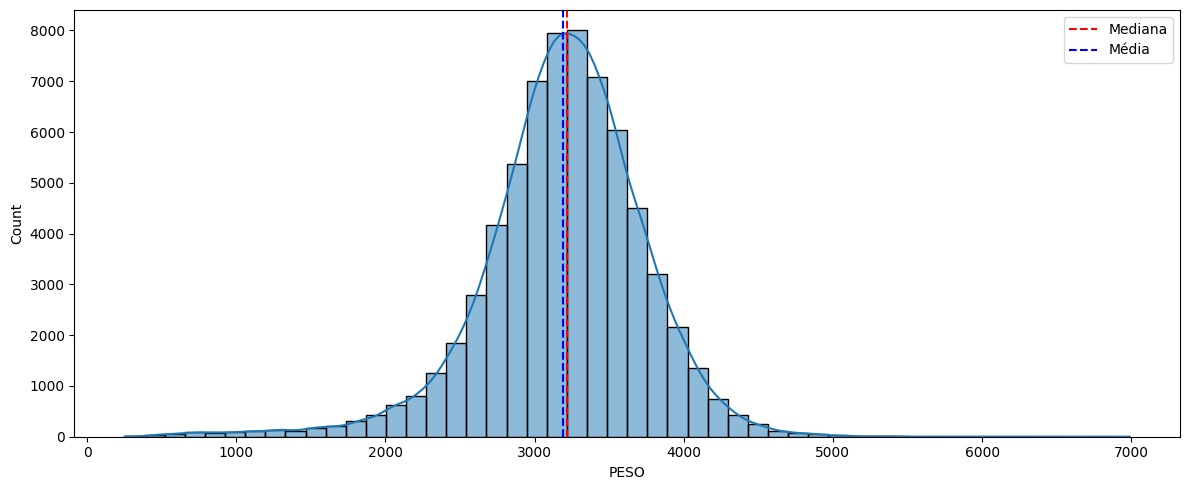

In [15]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.histplot(df['PESO'], bins=50, kde=True)
ax.axvline(x= df['PESO'].median(),linestyle='--',color='red',label='Mediana')
ax.axvline(x= df['PESO'].mean(),linestyle='--',color='blue',label='Média')
plt.legend()
plt.tight_layout()
plt.show()

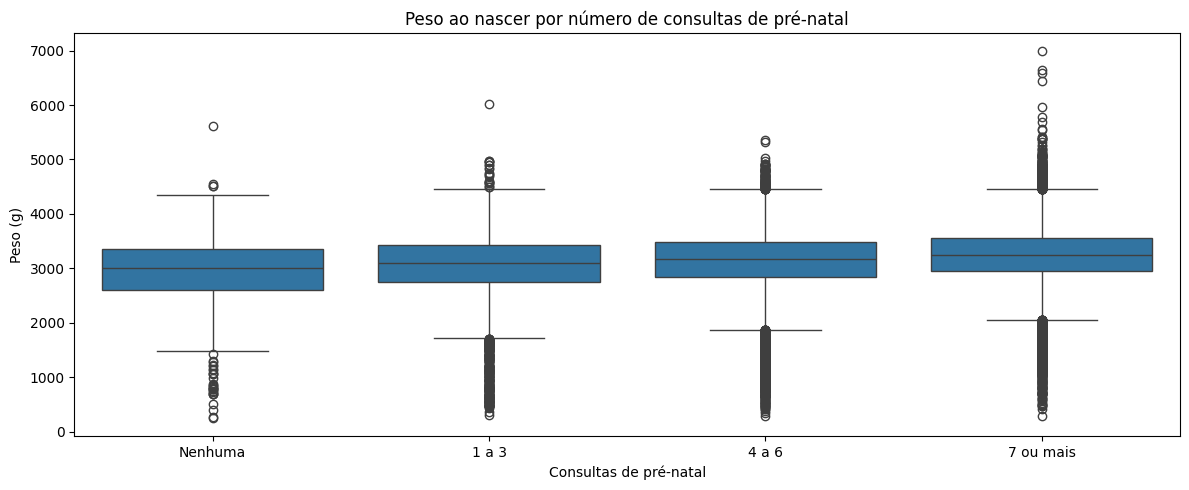

In [16]:
ordem_consultas = ['Nenhuma', '1 a 3', '4 a 6', '7 ou mais']

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=df, x='CONSULTAS_DESC', y='PESO', order=ordem_consultas, ax=ax)
ax.set_title('Peso ao nascer por número de consultas de pré-natal')
ax.set_xlabel('Consultas de pré-natal')
ax.set_ylabel('Peso (g)')
plt.tight_layout()
plt.show()

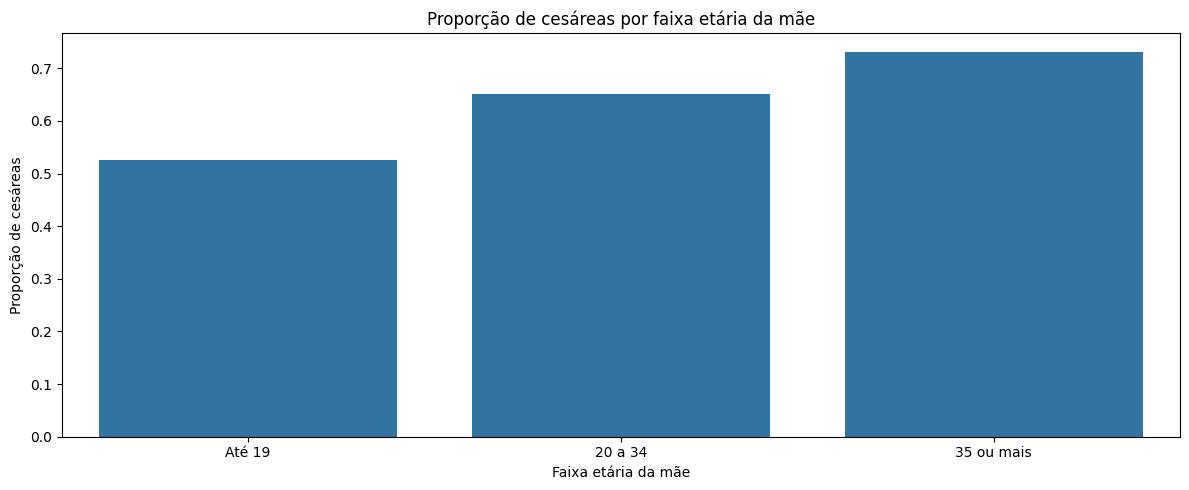

In [17]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=df, x='FAIXA_IDADE_MAE', y='CESAREA', errorbar=None, ax=ax)
ax.set_title('Proporção de cesáreas por faixa etária da mãe')
ax.set_xlabel('Faixa etária da mãe')
ax.set_ylabel('Proporção de cesáreas')
plt.tight_layout()
plt.show()

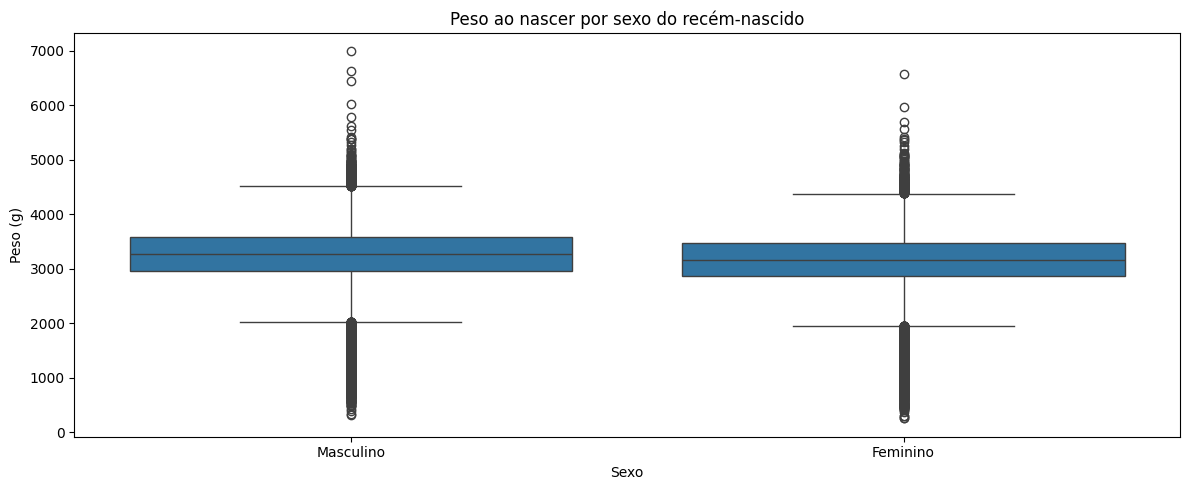

In [18]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=df, x='SEXO_DESC', y='PESO', ax=ax)
ax.set_title('Peso ao nascer por sexo do recém-nascido')
ax.set_xlabel('Sexo')
ax.set_ylabel('Peso (g)')
plt.tight_layout()
plt.show()

## Pressuposto de normalidade

O IC e o teste t para média pedem que a média amostral seja aproximadamente normal. Com mais de 70 mil observações isso vale pelo Teorema Central do Limite, mesmo com o peso um pouco assimétrico. Não usei Shapiro-Wilk porque com n tão grande ele rejeita a normalidade até para desvios sem importância. Olhei o QQ-plot e a assimetria.

-0.7247956469667238
2.6084234509057307


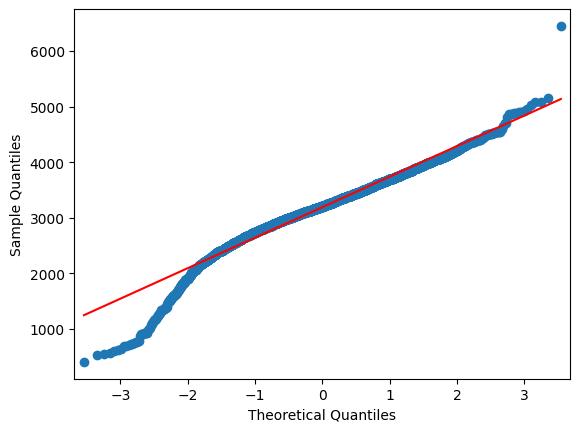

In [19]:
peso = df['PESO'].dropna()

print(stats.skew(peso))
print(stats.kurtosis(peso))

sm.qqplot(peso.sample(5000, random_state=42), line='s')
plt.show()

## Intervalos de confiança

Para a média do peso usei a distribuição t com n - 1 graus de liberdade, porque o desvio padrão da população não é conhecido. Conferi o resultado com um IC por bootstrap, que não depende de pressuposto sobre a distribuição.

In [20]:
n = len(peso)
media = peso.mean()
erro_padrao = stats.sem(peso)

dist = stats.t(df=n - 1, loc=media, scale=erro_padrao)
inf, sup = dist.interval(0.95)

print(f'n = {n} | média = {media:.2f} | erro padrão = {erro_padrao:.3f}')
print(f'IC 95% (t): [{inf:.2f}, {sup:.2f}]')

n = 67660 | média = 3192.40 | erro padrão = 2.096
IC 95% (t): [3188.29, 3196.51]


In [21]:
valores = peso.to_numpy()
rng = np.random.default_rng(42)

medias_boot = []
for i in range(2000):
    amostra = rng.choice(valores, size=len(valores), replace=True)
    medias_boot.append(amostra.mean())

inf_boot, sup_boot = np.percentile(medias_boot, [2.5, 97.5])
print(f'IC 95% (bootstrap): [{inf_boot:.2f}, {sup_boot:.2f}]')

IC 95% (bootstrap): [3188.18, 3196.63]


In [22]:
for coluna in ['CESAREA', 'BAIXO_PESO', 'PREMATURO', 'PRENATAL_ADEQUADO']:
    serie = df[coluna].dropna()
    n = len(serie)
    p = serie.mean()
    erro_padrao = np.sqrt(p * (1 - p) / n)
    dist = stats.norm(loc=p, scale=erro_padrao)
    inf, sup = dist.interval(0.95)
    print(f'{coluna}: p = {p:.4f} | IC 95% = [{inf:.4f}, {sup:.4f}]')

CESAREA: p = 0.6365 | IC 95% = [0.6329, 0.6401]
BAIXO_PESO: p = 0.0829 | IC 95% = [0.0808, 0.0850]
PREMATURO: p = 0.1301 | IC 95% = [0.1275, 0.1326]
PRENATAL_ADEQUADO: p = 0.7954 | IC 95% = [0.7924, 0.7985]
